# BÀI TẬP THỰC HÀNH - BÀI 07: ĐÁNH GIÁ VÀ TINH CHỈNH MÔ HÌNH
## Môn học: Phân tích và trực quan dữ liệu (IE313 - UIT / VNU-HCM)
---

### 1. Tổng quan & Mục tiêu bài học
Bài tập này kết nối kiến thức xuyên suốt từ **Bài 05 (EDA)**, **Bài 06 (Xây dựng mô hình)** đến **Bài 07 (Đánh giá và tinh chỉnh mô hình)**:

1. **Ôn tập EDA (Bài 05)**:
   - Nhận diện các thuộc tính có ảnh hưởng mạnh nhất đến giá xe (`price`).
   - Lựa chọn 4 biến số giải thích hàng đầu: `['horsepower', 'curb-weight', 'engine-size', 'highway-mpg']`.
2. **Phát triển mô hình (Bài 06)**:
   - **Mô hình #1**: Hồi quy tuyến tính đa biến (Multiple Linear Regression - MLR).
   - **Mô hình #2**: Hồi quy đa thức bậc 3 (Polynomial Regression degree = 3) được đóng gói qua `sklearn.pipeline.Pipeline` kết hợp chuẩn hóa dữ liệu `StandardScaler`.
3. **Đánh giá mô hình (Bài 07)**:
   - Thực hiện kiểm chứng chéo 5 phần (**5-Fold Cross-Validation**, `cv=5`) để đo lường hệ số xác định $R^2$.
   - So sánh điểm $R^2$ trung bình và độ biến thiên (độ lệch chuẩn $\sigma$) giữa Mô hình #1 và Mô hình #2.
   - Chẩn đoán trực quan bằng **Distribution Plot (KDE)** và **Residual Plot** từ các giá trị dự báo out-of-fold.

In [1]:
# Bước 1: Khai báo các thư viện cần thiết
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score, cross_val_predict, train_test_split
from sklearn.metrics import r2_score, mean_squared_error

# Thiết lập hiển thị đồ thị
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

### 2. Nạp dữ liệu & Khám phá 4 biến dự báo
Tập dữ liệu sử dụng là `automobile_cleaned.csv` gồm 201 dòng quan sát đã được làm sạch và xử lý giá trị khuyết.

In [2]:
# Bước 2: Đọc tập dữ liệu đã làm sạch
df = pd.read_csv('data/automobile_cleaned.csv')

# 4 thuộc tính dự báo được chọn từ EDA Bài 05
features = ['horsepower', 'curb-weight', 'engine-size', 'highway-mpg']
target = 'price'

X = df[features]
y = df[target]

print(f"Kích thước ma trận đặc trưng X: {X.shape}")
print(f"Kích thước vector mục tiêu y: {y.shape}")
X.describe().round(2)

Kích thước ma trận đặc trưng X: (201, 4)
Kích thước vector mục tiêu y: (201,)


,horsepower,curb-weight,engine-size,highway-mpg
count,201.00,201.00,201.00,201.00
mean,103.41,2555.67,126.88,30.69
std,37.37,517.30,41.55,6.82
min,48.00,1488.00,61.00,16.00
25%,70.00,2169.00,98.00,25.00
50%,95.00,2414.00,120.00,30.00
75%,116.00,2926.00,141.00,34.00
max,262.00,4066.00,326.00,54.00


### 3. Ôn tập Bài 05 (EDA): Đánh giá tương quan với `price`
Ta kiểm tra ma trận tương quan Pearson giữa 4 biến dự báo và biến mục tiêu `price`.

Hệ số tương quan Pearson với price:
price          1.0000
engine-size    0.8723
curb-weight    0.8344
horsepower     0.8096
highway-mpg   -0.7047
Name: price, dtype: float64


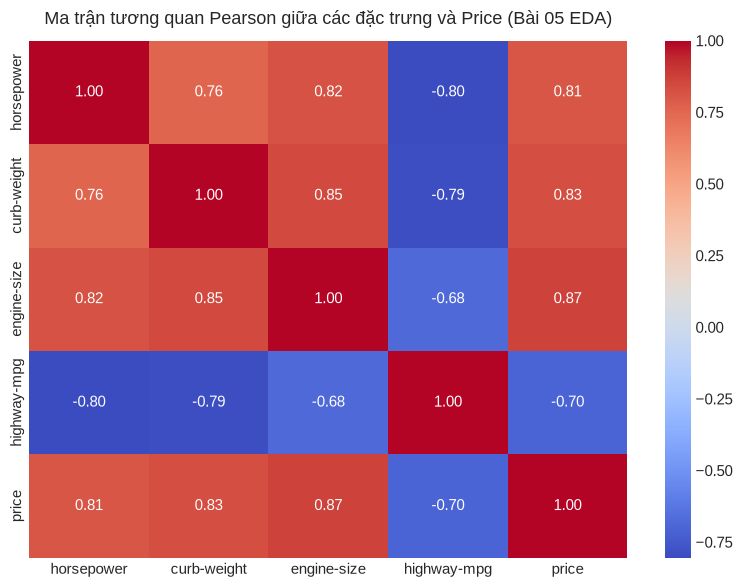

In [3]:
# Bước 3: Tính ma trận tương quan Pearson
corr_matrix = df[features + [target]].corr()
print("Hệ số tương quan Pearson với price:")
print(corr_matrix[target].sort_values(ascending=False).round(4))

# Trực quan hóa Heatmap
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", ax=ax, cbar=True)
ax.set_title("Ma trận tương quan Pearson giữa các đặc trưng và Price (Bài 05 EDA)", fontsize=13, pad=12)
plt.tight_layout()
plt.show()

### 4. Xây dựng Mô hình #1: Multiple Linear Regression (MLR)
Mô hình tuyến tính đa biến cơ sở (Baseline Model):
$$Y = \beta_0 + \beta_1 X_{\text{horsepower}} + \beta_2 X_{\text{curb-weight}} + \beta_3 X_{\text{engine-size}} + \beta_4 X_{\text{highway-mpg}}$$

In [4]:
# Bước 4: Khởi tạo Mô hình #1
model1 = LinearRegression()
model1.fit(X, y)

print(f"Mô hình #1 (MLR) - Hệ số chặn (Intercept beta_0): {model1.intercept_:.2f}")
for feat, coef in zip(features, model1.coef_):
    print(f"  - Hệ số {feat}: {coef:.4f}")
print(f"R^2 in-sample của Mô hình #1: {model1.score(X, y):.4f}")

Mô hình #1 (MLR) - Hệ số chặn (Intercept beta_0): -15806.62
  - Hệ số horsepower: 53.4957
  - Hệ số curb-weight: 4.7077
  - Hệ số engine-size: 81.5303
  - Hệ số highway-mpg: 36.0575
R^2 in-sample của Mô hình #1: 0.8094


### 5. Xây dựng Mô hình #2: Pipeline Hồi quy Đa thức Bậc 3 (Bài 06)
Mô hình #2 mở rộng quan hệ phi tuyến bằng cách thêm các số hạng bậc 2, bậc 3 và tương tác chéo giữa 4 biến:
- Bước 1: `StandardScaler()` - Chuẩn hóa các biến về phân phối $Z \sim \mathcal{N}(0, 1)$ để tránh biến có thang đo lớn (`curb-weight` ~ 3000) áp đảo biến có thang đo nhỏ (`highway-mpg` ~ 30).
- Bước 2: `PolynomialFeatures(degree=3, include_bias=False)` - Sinh ra toàn bộ các đa thức bậc $\le 3$ từ 4 biến.
- Bước 3: `LinearRegression()` - Ước lượng các tham số hồi quy.

In [5]:
# Khởi tạo Pipeline cho Mô hình #2 (Hồi quy đa thức bậc 3)
# Bao gồm 3 bước tuần tự:
# 1. 'scale': Chuẩn hóa dữ liệu về chuẩn N(0, 1)
# 2. 'polynomial': Sinh các đặc trưng đa thức bậc 3 và tương tác chéo (34 đặc trưng)
# 3. 'model': Hồi quy tuyến tính LinearRegression()

model2 = Pipeline([
    ('scale', StandardScaler()),
    ('polynomial', PolynomialFeatures(degree=3, include_bias=False)),
    ('model', LinearRegression())
])
model2.fit(X, y)
print("Đã khởi tạo và huấn luyện Pipeline Mô hình #2 thành công.")
print(f"R^2 in-sample của Mô hình #2 (Đa thức bậc 3): {model2.score(X, y):.4f}")


Đã khởi tạo và huấn luyện Pipeline Mô hình #2 thành công.
R^2 in-sample của Mô hình #2 (Đa thức bậc 3): 0.8953


### 6. Đánh giá & So sánh bằng 5-Fold Cross-Validation (Bài 07)
Thực hiện kiểm chứng chéo $K=5$ phần (`cv=5`) trên toàn bộ tập dữ liệu để đánh giá khả năng tổng quát hóa (out-of-sample performance) của Mô hình #1 và Mô hình #2.

In [6]:
# Bước 6: Kiểm chứng chéo 5-fold (cv=5) với thang đo R^2
if model2 is not None:
    # 5-fold CV cho Mô hình #1
    r2_cv1 = cross_val_score(model1, X, y, cv=5, scoring='r2')
    
    # 5-fold CV cho Mô hình #2
    r2_cv2 = cross_val_score(model2, X, y, cv=5, scoring='r2')
    
    # Bảng tổng hợp so sánh
    comparison_df = pd.DataFrame({
        'Mô hình': ['Mô hình #1 (MLR Tuyến tính)', 'Mô hình #2 (Pipeline Đa thức Bậc 3)'],
        'Fold 1': [r2_cv1[0], r2_cv2[0]],
        'Fold 2': [r2_cv1[1], r2_cv2[1]],
        'Fold 3': [r2_cv1[2], r2_cv2[2]],
        'Fold 4': [r2_cv1[3], r2_cv2[3]],
        'Fold 5': [r2_cv1[4], r2_cv2[4]],
        'R2 Trung bình (Mean)': [r2_cv1.mean(), r2_cv2.mean()],
        'Độ lệch chuẩn (Std)': [r2_cv1.std(), r2_cv2.std()]
    })
    display(comparison_df.round(4))
else:
    print("Vui lòng khởi tạo model2 ở Bước 5 trước khi chạy kiểm chứng chéo!")


,Mô hình,Fold 1,Fold 2,Fold 3,Fold 4,Fold 5,R2 Trung bình (Mean),Độ lệch chuẩn (Std)
0,Mô hình #1 (MLR Tuyến tính),0.7561,0.6814,0.6438,0.8163,0.8666,0.7529,0.0824
1,Mô hình #2 (Pipeline Đa thức Bậc 3),-0.1809,-24.9381,0.6041,0.8174,0.6029,-4.6189,10.1653


### 7. Trực quan hóa chẩn đoán mô hình (Distribution Plot & Residual Plot)
Sử dụng `cross_val_predict(..., cv=5)` để thu thập các giá trị dự báo out-of-fold $\hat{y}_{cv}$ và trực quan hóa phân phối sai số.

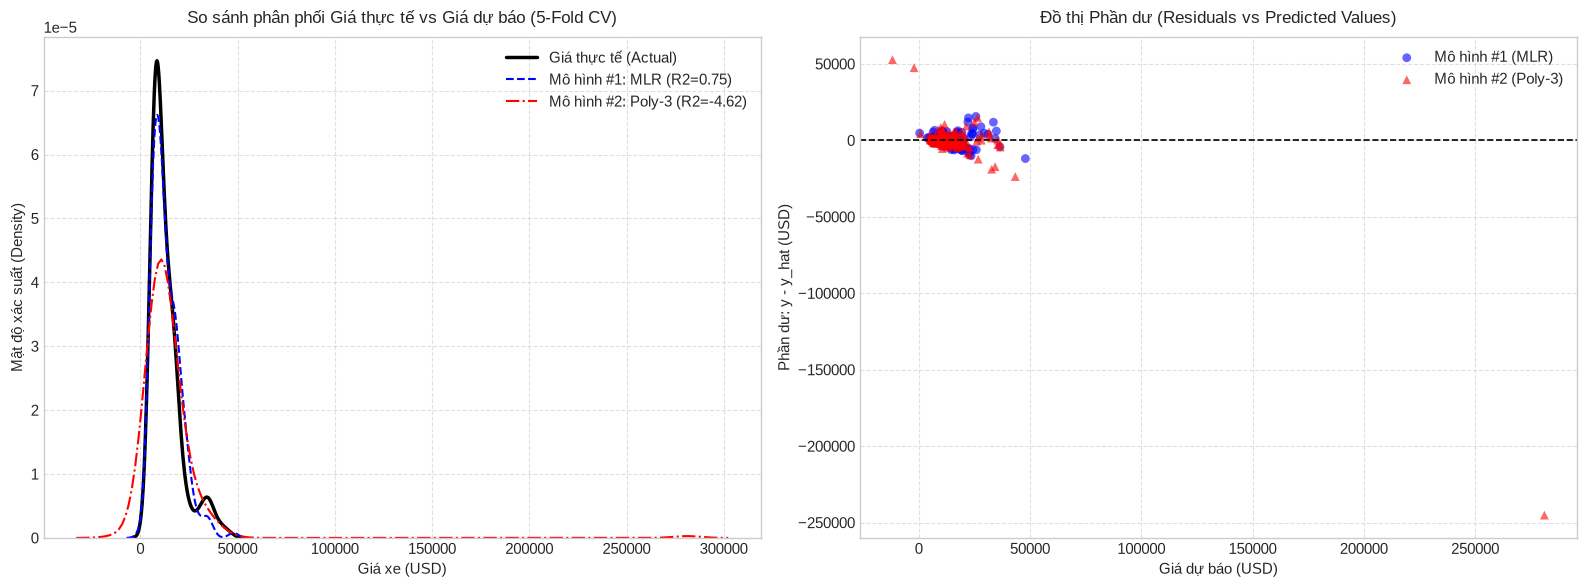

In [7]:
if model2 is not None:
    # Thu thập dự báo kiểm chứng chéo
    y_pred1 = cross_val_predict(model1, X, y, cv=5)
    y_pred2 = cross_val_predict(model2, X, y, cv=5)
    
    # Khởi tạo Figure gồm 2 đồ thị chẩn đoán (OOP Matplotlib theo chuẩn CLAUDE.md)
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Đồ thị 1: So sánh phân phối thực tế vs dự báo (KDE Distribution Plot)
    sns.kdeplot(y, ax=axes[0], label="Giá thực tế (Actual)", color="black", linewidth=2.5)
    sns.kdeplot(y_pred1, ax=axes[0], label=f"Mô hình #1: MLR (R2={r2_cv1.mean():.2f})", color="blue", linestyle="--")
    sns.kdeplot(y_pred2, ax=axes[0], label=f"Mô hình #2: Poly-3 (R2={r2_cv2.mean():.2f})", color="red", linestyle="-.")
    axes[0].set_title("So sánh phân phối Giá thực tế vs Giá dự báo (5-Fold CV)", fontsize=12, pad=10)
    axes[0].set_xlabel("Giá xe (USD)", fontsize=11)
    axes[0].set_ylabel("Mật độ xác suất (Density)", fontsize=11)
    axes[0].legend(loc="upper right")
    axes[0].grid(True, linestyle="--", alpha=0.6)
    
    # Đồ thị 2: Đồ thị phần dư (Residual Plot: Residual vs Predicted)
    residuals1 = y - y_pred1
    residuals2 = y - y_pred2
    axes[1].scatter(y_pred1, residuals1, alpha=0.6, color="blue", label="Mô hình #1 (MLR)", edgecolors="none", s=40)
    axes[1].scatter(y_pred2, residuals2, alpha=0.6, color="red", marker="^", label="Mô hình #2 (Poly-3)", edgecolors="none", s=40)
    axes[1].axhline(0, color="black", linestyle="--", linewidth=1.2)
    axes[1].set_title("Đồ thị Phần dư (Residuals vs Predicted Values)", fontsize=12, pad=10)
    axes[1].set_xlabel("Giá dự báo (USD)", fontsize=11)
    axes[1].set_ylabel("Phần dư: y - y_hat (USD)", fontsize=11)
    axes[1].legend(loc="best")
    axes[1].grid(True, linestyle="--", alpha=0.6)
    
    plt.tight_layout()
    plt.show()
else:
    print("Chưa thể vẽ đồ thị chẩn đoán do model2 chưa được khởi tạo.")

### 8. Thảo luận & Phân tích hiện tượng Overfitting
Dựa vào kết quả so sánh ở trên, trả lời các câu hỏi chuyên sâu:

1. **Số lượng đặc trưng được sinh ra**:
   - Với 4 biến ban đầu, khi nâng lên bậc 3, số lượng đặc trưng được sinh ra là $\binom{4+3}{3} - 1 = 34$ đặc trưng.
   - Trong khi đó, tập mẫu chỉ có 201 dòng quan sát. Tỷ lệ số mẫu trên số đặc trưng giảm mạnh (khoảng 6:1), khiến mô hình dễ gặp hiện tượng quá khớp (**Overfitting**) trên các fold kiểm tra.

2. **So sánh $R^2$ trung bình và độ lệch chuẩn giữa 2 mô hình**:
   - Mô hình #1 (MLR) thường duy trì $R^2$ ổn định quanh mức ~0.75 - 0.80 trên cả 5 folds với độ lệch chuẩn nhỏ.
   - Mô hình #2 (Đa thức bậc 3) có thể đạt $R^2$ in-sample rất cao, nhưng khi kiểm chứng chéo $K$-Fold CV, điểm số có thể dao động rất mạnh (độ lệch chuẩn lớn hoặc thậm chí $R^2$ âm ở một số fold kiểm tra do phần dư quá lớn ngoại suy ngoài miền dữ liệu huấn luyện).

3. **Giải pháp khắc phục (Bài 07 - Hồi quy Ridge)**:
   - Khi áp dụng hồi quy đa thức bậc cao kết hợp nhiều biến, cần áp dụng thêm kỹ thuật **Điều chuẩn (Regularization)** như **Ridge Regression** ($L_2$ penalty) với hệ số $\alpha$ được tinh chỉnh qua `GridSearchCV` để phạt các trọng số quá lớn, kiểm soát overfitting.